In [1]:
# 16일차 폴더에 있는 성적 데이터를 이용
# 데이터 생성
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('성적데이터.csv')
df

,hour,absent,place,score
0,0.5,3,Home,10
1,1.2,4,Library,8
2,1.8,2,Cafe,14
3,2.4,0,Cafe,26
4,2.6,2,Home,22
5,3.2,0,Home,30
6,3.9,0,Library,42
7,4.4,0,Library,48
8,4.5,5,Home,38
9,5.0,1,Cafe,58


In [2]:
# 독립, 종속 분리
import numpy as np
X = df.iloc[: , :-1] # 장소도 제외하기 위해서
y = df.iloc[: , -1]

In [3]:
# 원핫인코딩 => 범주형 데이터를 수치로 변환
# 8일차 05_다중선형회귀2에서 참고
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'), [2])], remainder='passthrough')
X = ct.fit_transform(X)
print(X)

[[ 1.   0.   0.5  3. ]
 [ 0.   1.   1.2  4. ]
 [ 0.   0.   1.8  2. ]
 [ 0.   0.   2.4  0. ]
 [ 1.   0.   2.6  2. ]
 [ 1.   0.   3.2  0. ]
 [ 0.   1.   3.9  0. ]
 [ 0.   1.   4.4  0. ]
 [ 1.   0.   4.5  5. ]
 [ 0.   0.   5.   1. ]
 [ 0.   0.   5.3  2. ]
 [ 0.   0.   5.8  0. ]
 [ 0.   1.   6.   3. ]
 [ 0.   0.   6.1  1. ]
 [ 0.   1.   6.2  1. ]
 [ 1.   0.   6.9  4. ]
 [ 0.   0.   7.2  2. ]
 [ 1.   0.   8.4  1. ]
 [ 0.   1.   8.6  1. ]
 [ 0.   1.  10.   0. ]]


In [4]:
# 학습, 훈련 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# 정규화 
from tensorflow.keras import models, layers
import numpy as np
nomalizer = layers.Normalization(axis=-1)
nomalizer.adapt(np.array(X_train))
# 모델 설계
model = models.Sequential([
	nomalizer,
	layers.Dense(64, activation='relu'),
	layers.Dense(32, activation='relu'),
	layers.Dense(16, activation='relu'),
	layers.Dense(1, activation='linear'),
])

In [6]:
# 모델 설정
model.compile(optimizer='adam',
							loss='mse',
							metrics=['accuracy'])

In [7]:
# 학습
history = model.fit(X_train, y_train, epochs=1000, batch_size=50, verbose=0, validation_split=0.2)

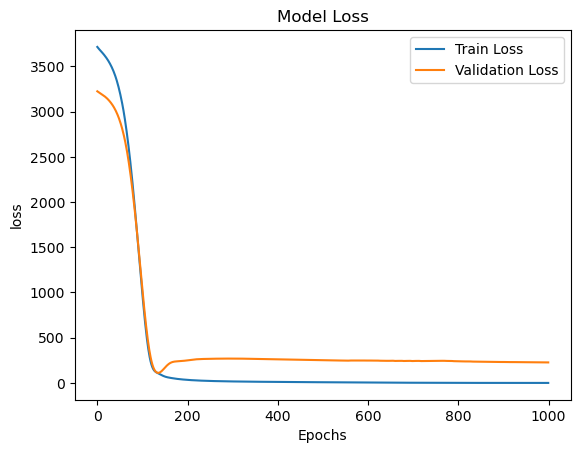

In [8]:
# 평가
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [13]:
# 평가
# 원핫인코딩으로 X_test를 변환
import tensorflow as tf
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'절대값 오차 평균 : {tf.sqrt(test_loss) * y_test.size}')
predictions = model.predict(np.array(X_test))
size = y_test.size

for i in range(size):
	print(f'예측값 : {predictions[i][0]}, 실제값 : {y_test.values[i]}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.0000e+00 - loss: 474.1779
절대값 오차 평균 : 87.10250854492188
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
예측값 : 19.129947662353516, 실제값 : 10
예측값 : 60.32621383666992, 실제값 : 86
예측값 : 50.35643768310547, 실제값 : 58
예측값 : 41.10269546508789, 실제값 : 8


In [28]:
# 예측
# 집에서 5시간공부하고 결석 0
# 도서관에서 5시간 공부하고 결석 0
# 집에서 7시간 공부하고 결석 3
# 카페에서 6시간 공부하고 결석 2
predictions = model.predict(np.array([[1,0,5,0],[0,1,5,0],[1,0,7,3]]))
print(f'예측값 : {predictions}')

new_dataset = [
	[5,0, 'Home'],
	[5,0, 'Library'],
	[7,3, 'Home'],
	[7,0, 'Cafe'],
]

new_dataset_encodng = ct.transform(new_dataset)
print(new_dataset_encodng)
predictions2 = model.predict(np.array(new_dataset_encodng, 'float32'))

for i in range(4):
	print(f'학습시간 : {new_dataset[i][0]},'
			+ f'장소 : {new_dataset[i][2]},'
			+ f'결석 : {new_dataset[i][1]},'
			+ f'예측 성적 : {predictions2[i][0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
예측값 : [[37.45242 ]
 [36.616825]
 [45.359825]]
[[1.0 0.0 5 0]
 [0.0 1.0 5 0]
 [1.0 0.0 7 3]
 [0.0 0.0 7 0]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
학습시간 : 5,장소 : Home,결석 : 0,예측 성적 : 37.45241928100586
학습시간 : 5,장소 : Library,결석 : 0,예측 성적 : 36.616825103759766
학습시간 : 7,장소 : Home,결석 : 3,예측 성적 : 45.35982894897461
학습시간 : 7,장소 : Cafe,결석 : 0,예측 성적 : 86.87419891357422
